In [1]:
# -*- coding: utf-8 -*-
"""
============================================================================
 train_interaction_2class_checkpointed.py — SAPA: KEPALA INTERAKSI 2-KELAS
 (inspecting vs other) + 5-Fold CV + TEST HOLDOUT + CHECKPOINT/RESUME
============================================================================
 INPUT : interaction_2class_devpool.npz (80%, utk 5-fold CV)
         interaction_2class_test.npz    (20%, HELD-OUT, dibuka SEKALI di akhir)
 OUTPUT ke MODEL_DIR (models_interaction_2class/):
   - interaction2_head.pt / .json      (model final)
   - interaction2_cv_summary.json      (metrik 5-fold, mean±std)
   - interaction2_test_result.json     (evaluasi SEKALI di test holdout — ini
                                        angka generalisasi paling jujur)
   - checkpoint/ (progress per-fold, utk resume kalau Colab putus)

 CHECKPOINT/RESUME: kalau Colab disconnect di tengah training, jalankan
 ulang skrip ini dari CELL 1 — otomatis SKIP fold yang sudah selesai,
 lanjut dari fold berikutnya. Tidak perlu mulai dari nol.

 Copy tiap "# ===== CELL N =====" ke satu cell Colab. GPU T4 cukup.
============================================================================
"""

# ===== CELL 1: Mount + Import + Konfigurasi =====
from google.colab import drive
drive.mount('/content/drive')

import os, re, json, time, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, precision_score, matthews_corrcoef,
                             cohen_kappa_score, confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
from tqdm.auto import tqdm
import pandas as pd
import matplotlib.pyplot as plt

BASE       = "/content/drive/MyDrive/Belajar AI/Compfest/Dataset"
DATA_DIR   = f"{BASE}/preprocessed_interaction_2class"
NPZ_DEV    = f"{DATA_DIR}/interaction_2class_devpool.npz"
NPZ_TEST   = f"{DATA_DIR}/interaction_2class_test.npz"
MODEL_DIR  = f"{BASE}/models_interaction_2class"
CKPT_DIR   = f"{MODEL_DIR}/checkpoint"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

JOINTS = list(range(17)); USE_CHANNELS = 3   # 17 sendi x (x,y,conf) — conf ASLI dari YOLOv8
CLASS_NAMES = ["other", "inspecting"]; N_CLASSES = 2
TARGET_CLASS = 1   # "inspecting" — kelas yang recall-nya paling kita pedulikan
METRIC_COLS = ["acc", "bal_acc", "macroF1", "weightedF1", "recall_inspecting", "mcc", "kappa"]

SEED, HIDDEN, LAYERS, DROPOUT = 42, 128, 2, 0.3
LR, WEIGHT_DECAY, BATCH       = 1e-3, 1e-4, 128
EPOCHS, PATIENCE, GRAD_CLIP   = 40, 8, 5.0
LR_FACTOR, LR_PATIENCE        = 0.5, 4
N_FOLDS                       = 5
MONITOR                       = "macroF1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)




Mounted at /content/drive
Device: cuda


In [2]:
# ===== CELL 2: Load dev-pool (utk CV) + test (disimpan, JANGAN dibuka dulu) =====
d = np.load(NPZ_DEV, allow_pickle=True)
kp = d["keypoints"]; y = d["labels"].astype(np.int64); meta = d["meta"].astype(str)
N = kp.shape[0]
print(f"[DEV-POOL] Total jendela: {N} | distribusi: "
      f"{ {CLASS_NAMES[c]: int((y==c).sum()) for c in range(N_CLASSES)} }")

X = kp[:, :, JOINTS, :USE_CHANNELS].reshape(N, kp.shape[1], -1).astype(np.float32)
IN_DIM = X.shape[-1]
def subject(s): return s.split("_")[0]
groups = np.array([subject(m) for m in meta])
print(f"X: {X.shape} | in_dim: {IN_DIM} | jumlah subjek (dev-pool): {len(set(groups))}")

# test HANYA di-load metadata-nya dulu (verifikasi tidak overlap), DATA-nya
# baru benar-benar dipakai di CELL 7 (akhir, sekali saja).
d_test = np.load(NPZ_TEST, allow_pickle=True)
test_meta = d_test["meta"].astype(str)
test_subjects = set(subject(m) for m in test_meta)
dev_subjects = set(groups)
assert dev_subjects.isdisjoint(test_subjects), "BOCOR: subjek test ada di dev-pool!"
print(f"✓ Verifikasi: {len(test_subjects)} subjek test terpisah total dari {len(dev_subjects)} subjek dev-pool.")




[DEV-POOL] Total jendela: 10948 | distribusi: {'other': 6017, 'inspecting': 4931}
X: (10948, 45, 51) | in_dim: 51 | jumlah subjek (dev-pool): 33
✓ Verifikasi: 8 subjek test terpisah total dari 33 subjek dev-pool.


In [3]:
# ===== CELL 3: Model + fungsi bantu =====
class InteractionLSTM2(nn.Module):
    def __init__(self, in_dim, hidden=128, layers=2, n_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.head = nn.Sequential(nn.LayerNorm(hidden*2), nn.Dropout(dropout),
                                  nn.Linear(hidden*2, n_classes))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out.mean(dim=1))

def make_loader(idx, shuffle):
    return DataLoader(TensorDataset(torch.tensor(X[idx]), torch.tensor(y[idx])),
                      batch_size=BATCH, shuffle=shuffle)

def full_metrics(yt, yp):
    return {"acc": accuracy_score(yt, yp),
            "bal_acc": balanced_accuracy_score(yt, yp),
            "macroF1": f1_score(yt, yp, average='macro', zero_division=0),
            "weightedF1": f1_score(yt, yp, average='weighted', zero_division=0),
            "recall_inspecting": recall_score(yt, yp, labels=[TARGET_CLASS], average='macro', zero_division=0),
            "mcc": matthews_corrcoef(yt, yp),
            "kappa": cohen_kappa_score(yt, yp)}

def predict_proba(model, dl):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for xb, yb in dl:
            logit = model(xb.to(DEVICE))
            ps.append(torch.softmax(logit, dim=1).cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def train_one_fold(fold, idx_tr, idx_va):
    cnt = np.bincount(y[idx_tr], minlength=N_CLASSES).astype(np.float32)
    cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
    model     = InteractionLSTM2(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                           factor=LR_FACTOR, patience=LR_PATIENCE)
    dl_tr = make_loader(idx_tr, True)
    dl_va = make_loader(idx_va, False)
    best, best_ep, wait, best_state, hist = -1.0, 0, 0, None, []
    for ep in range(1, EPOCHS + 1):
        model.train(); run = 0.0
        pbar = tqdm(dl_tr, desc=f"Fold {fold} Ep {ep:02d}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step(); run += loss.item() * len(yb); pbar.set_postfix(loss=f"{loss.item():.4f}")
        yv, pv_prob = predict_proba(model, dl_va)
        mv = full_metrics(yv, pv_prob.argmax(1))
        scheduler.step(mv[MONITOR]); lr_now = optimizer.param_groups[0]['lr']
        hist.append({"fold": fold, "epoch": ep, "train_loss": round(run/len(idx_tr), 4),
                     **{k: round(v, 4) for k, v in mv.items()}, "lr": lr_now})
        print(f"  fold {fold} ep {ep:02d} | loss {run/len(idx_tr):.4f} | "
              f"macroF1 {mv['macroF1']:.3f} | recall_inspecting {mv['recall_inspecting']:.3f}")
        if mv[MONITOR] > best:
            best, best_ep, wait = mv[MONITOR], ep, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  [fold {fold}] early stop @ ep {ep} (best {best:.3f} @ {best_ep})")
                break
    model.load_state_dict(best_state)
    yv, pv_prob = predict_proba(model, dl_va)
    return best_state, hist, full_metrics(yv, pv_prob.argmax(1)), best_ep, pv_prob




In [4]:
# ===== CELL 4: 5-Fold CV DENGAN CHECKPOINT/RESUME =====
# Kalau Colab putus di tengah, jalankan ulang dari CELL 1 -> otomatis
# lanjut dari fold terakhir yang BELUM selesai (bukan mulai dari 0 lagi).

CKPT_PROGRESS = f"{CKPT_DIR}/progress.json"
CKPT_OOF_PROB = f"{CKPT_DIR}/oof_prob.npy"
CKPT_OOF_DONE = f"{CKPT_DIR}/oof_done.npy"
CKPT_HISTORY  = f"{CKPT_DIR}/history.json"
CKPT_FOLDMET  = f"{CKPT_DIR}/fold_metrics.json"

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits = list(sgkf.split(X, y, groups))   # fix urutan fold, konsisten antar-run

# --- muat checkpoint kalau ada, kalau tidak mulai dari nol ---
if os.path.exists(CKPT_PROGRESS):
    with open(CKPT_PROGRESS) as f:
        progress = json.load(f)
    completed_folds = set(progress["completed_folds"])
    oof_prob = np.load(CKPT_OOF_PROB)
    oof_done = np.load(CKPT_OOF_DONE)
    with open(CKPT_HISTORY) as f:
        all_history = json.load(f)
    with open(CKPT_FOLDMET) as f:
        fold_metrics = json.load(f)
    best_epochs = [m["best_epoch"] for m in fold_metrics]
    print(f"[RESUME] Melanjutkan dari checkpoint. Fold selesai: {sorted(completed_folds)}")
else:
    completed_folds = set()
    oof_prob = np.zeros((N, N_CLASSES), np.float32)
    oof_done = np.zeros(N, bool)
    all_history, fold_metrics, best_epochs = [], [], []
    print("[MULAI BARU] Tidak ada checkpoint, training dari fold 0.")

def save_checkpoint():
    """Panggil setelah TIAP fold selesai — supaya progress tidak hilang."""
    with open(CKPT_PROGRESS, "w") as f:
        json.dump({"completed_folds": sorted(completed_folds)}, f)
    np.save(CKPT_OOF_PROB, oof_prob)
    np.save(CKPT_OOF_DONE, oof_done)
    with open(CKPT_HISTORY, "w") as f:
        json.dump(all_history, f)
    with open(CKPT_FOLDMET, "w") as f:
        json.dump(fold_metrics, f)
    print(f"  [checkpoint disimpan] fold selesai: {sorted(completed_folds)}")

for fold, (idx_tr, idx_va) in enumerate(fold_splits):
    if fold in completed_folds:
        print(f"=== FOLD {fold}: SUDAH SELESAI (dari checkpoint), skip ===")
        continue
    assert set(groups[idx_tr]).isdisjoint(set(groups[idx_va]))
    print(f"\n=== FOLD {fold} | train {len(idx_tr)} / val {len(idx_va)} "
          f"({len(set(groups[idx_va]))} subjek) ===")
    _, hist, mets, best_ep, pv_prob = train_one_fold(fold, idx_tr, idx_va)
    oof_prob[idx_va] = pv_prob; oof_done[idx_va] = True
    all_history += hist; best_epochs.append(best_ep)
    fold_metrics.append({"fold": fold, **{k: round(mets[k], 4) for k in METRIC_COLS}, "best_epoch": best_ep})
    completed_folds.add(fold)
    print(f"--- Fold {fold}: macroF1 {mets['macroF1']:.3f} | recall_inspecting {mets['recall_inspecting']:.3f}")
    save_checkpoint()   # <<< PENTING: simpan progress SETIAP fold selesai

assert oof_done.all(), "OOF belum lengkap — ada fold yang gagal, cek error di atas."
oof_pred_argmax = oof_prob.argmax(1)
print("\n✓ Semua 5 fold selesai.")




[MULAI BARU] Tidak ada checkpoint, training dari fold 0.

=== FOLD 0 | train 9204 / val 1744 (6 subjek) ===


Fold 0 Ep 01:   0%|          | 0/72 [00:00<?, ?it/s]

  fold 0 ep 01 | loss 0.6794 | macroF1 0.699 | recall_inspecting 0.622


Fold 0 Ep 02:   0%|          | 0/72 [00:00<?, ?it/s]

  fold 0 ep 02 | loss 0.5510 | macroF1 0.685 | recall_inspecting 0.839


...

  fold 4 ep 27 | loss 0.2202 | macroF1 0.751 | recall_inspecting 0.739


Fold 4 Ep 28:   0%|          | 0/67 [00:00<?, ?it/s]

  fold 4 ep 28 | loss 0.2002 | macroF1 0.744 | recall_inspecting 0.722


Fold 4 Ep 29:   0%|          | 0/67 [00:00<?, ?it/s]

  fold 4 ep 29 | loss 0.1876 | macroF1 0.753 | recall_inspecting 0.756
  [fold 4] early stop @ ep 29 (best 0.761 @ 21)
--- Fold 4: macroF1 0.761 | recall_inspecting 0.741
  [checkpoint disimpan] fold selesai: [0, 1, 2, 3, 4]

✓ Semua 5 fold selesai.


In [5]:
# ===== CELL 5: Metrik CV + confusion matrix + simpan =====
fold_df = pd.DataFrame(fold_metrics)
print("=== Metrik per FOLD (2 kelas) ===")
print(fold_df.to_string(index=False))

summary = {k: {"mean": round(float(fold_df[k].mean()), 4), "std": round(float(fold_df[k].std(ddof=0)), 4)}
           for k in METRIC_COLS}
print("\n=== Ringkasan lintas fold (mean ± std) ===")
for k in METRIC_COLS:
    print(f"  {k:20s}: {summary[k]['mean']:.3f} ± {summary[k]['std']:.3f}")

cm = confusion_matrix(y, oof_pred_argmax, labels=[0,1])
print("\n=== OOF confusion matrix [other, inspecting] ===")
print(cm)
print(classification_report(y, oof_pred_argmax, labels=[0,1],
                            target_names=CLASS_NAMES, zero_division=0, digits=3))

with open(f"{MODEL_DIR}/interaction2_cv_summary.json", "w") as f:
    json.dump({"n_folds": N_FOLDS, "summary_mean_std": summary,
               "oof_confusion_matrix": cm.tolist()}, f, indent=2)
fold_df.to_csv(f"{MODEL_DIR}/interaction2_cv_folds.csv", index=False)

print(f"\n>>> PEMBANDING: hasil pos-hoc regroup 6-kelas kemarin macroF1=0.762")
print(f">>> Hasil TRAINING LANGSUNG 2-kelas ini: macroF1={summary['macroF1']['mean']:.3f}")
print(">>> (Kalau lebih tinggi = melatih langsung utk 2 kelas lebih baik dari regroup pasca-hoc)")




=== Metrik per FOLD (2 kelas) ===
 fold    acc  bal_acc  macroF1  weightedF1  recall_inspecting    mcc  kappa  best_epoch
    0 0.7706   0.7698   0.7690      0.7709             0.7618 0.5383 0.5381          13
    1 0.7536   0.7544   0.7512      0.7546             0.7601 0.5048 0.5032           6
    2 0.7929   0.7905   0.7913      0.7923             0.7427 0.5849 0.5833          22
    3 0.7694   0.7660   0.7655      0.7696             0.7407 0.5311 0.5310           8
    4 0.7621   0.7608   0.7609      0.7620             0.7407 0.5219 0.5219          21

=== Ringkasan lintas fold (mean ± std) ===
  acc                 : 0.770 ± 0.013
  bal_acc             : 0.768 ± 0.012
  macroF1             : 0.768 ± 0.013
  weightedF1          : 0.770 ± 0.013
  recall_inspecting   : 0.749 ± 0.010
  mcc                 : 0.536 ± 0.027
  kappa               : 0.535 ± 0.027

=== OOF confusion matrix [other, inspecting] ===
[[4723 1294]
 [1239 3692]]
              precision    recall  f1-score   suppo

In [6]:
# ===== CELL 6: Model FINAL (dilatih di SELURUH dev-pool) =====
final_epochs = max(3, int(round(np.mean(best_epochs))))
print(f"\nMelatih model FINAL di seluruh dev-pool ({N} window), {final_epochs} epoch.")
cnt = np.bincount(y, minlength=N_CLASSES).astype(np.float32)
cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
final = InteractionLSTM2(IN_DIM, HIDDEN, LAYERS, N_CLASSES, DROPOUT).to(DEVICE)
crit  = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
opt   = torch.optim.Adam(final.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
dl_all = make_loader(np.arange(N), True)
for ep in range(1, final_epochs + 1):
    final.train(); run = 0.0
    for xb, yb in tqdm(dl_all, desc=f"FINAL ep {ep:02d}", leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss = crit(final(xb), yb); loss.backward()
        torch.nn.utils.clip_grad_norm_(final.parameters(), GRAD_CLIP)
        opt.step(); run += loss.item()*len(yb)
    print(f"  FINAL ep {ep:02d} | loss {run/N:.4f}")

torch.save(final.state_dict(), f"{MODEL_DIR}/interaction2_head.pt")
config = {"arch": "InteractionLSTM2", "in_dim": IN_DIM, "hidden": HIDDEN, "layers": LAYERS,
          "dropout": DROPOUT, "n_classes": N_CLASSES, "class_names": CLASS_NAMES,
          "joints": JOINTS, "use_channels": USE_CHANNELS,
          "window": kp.shape[1], "fps": 15, "final_epochs": final_epochs,
          "cv_macroF1": summary["macroF1"], "cv_recall_inspecting": summary["recall_inspecting"]}
with open(f"{MODEL_DIR}/interaction2_head.json", "w") as f:
    json.dump(config, f, indent=2)
print(f"Model final tersimpan: {MODEL_DIR}/interaction2_head.pt")





Melatih model FINAL di seluruh dev-pool (10948 window), 14 epoch.


FINAL ep 01:   0%|          | 0/86 [00:00<?, ?it/s]

  FINAL ep 01 | loss 0.6336


FINAL ep 02:   0%|          | 0/86 [00:00<?, ?it/s]

  FINAL ep 02 | loss 0.5310


...

  FINAL ep 12 | loss 0.3863


FINAL ep 13:   0%|          | 0/86 [00:00<?, ?it/s]

  FINAL ep 13 | loss 0.3769


FINAL ep 14:   0%|          | 0/86 [00:00<?, ?it/s]

  FINAL ep 14 | loss 0.3609
Model final tersimpan: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models_interaction_2class/interaction2_head.pt


In [7]:
# ===== CELL 7: EVALUASI SEKALI di TEST HOLDOUT (angka generalisasi paling jujur) =====
# Ini pertama kalinya data test disentuh sama sekali. Tidak boleh dipakai
# untuk memilih model/hyperparameter — cuma pelaporan akhir.
kp_test = d_test["keypoints"]; y_test = d_test["labels"].astype(np.int64)
X_test = kp_test[:, :, JOINTS, :USE_CHANNELS].reshape(len(y_test), kp_test.shape[1], -1).astype(np.float32)

dl_test = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=BATCH)
y_test_true, test_prob = predict_proba(final, dl_test)
test_pred = test_prob.argmax(1)
test_metrics = full_metrics(y_test_true, test_pred)
test_cm = confusion_matrix(y_test_true, test_pred, labels=[0,1])

print("\n" + "="*60)
print("HASIL DI TEST HOLDOUT (20% subjek belum pernah dilihat model)")
print("="*60)
for k in METRIC_COLS:
    print(f"  {k:20s}: {test_metrics[k]:.3f}")
print("\nConfusion matrix test:")
print(test_cm)
print(classification_report(y_test_true, test_pred, labels=[0,1],
                            target_names=CLASS_NAMES, zero_division=0, digits=3))

with open(f"{MODEL_DIR}/interaction2_test_result.json", "w") as f:
    json.dump({"test_metrics": {k: round(v,4) for k,v in test_metrics.items()},
               "test_confusion_matrix": test_cm.tolist(),
               "n_test_window": len(y_test),
               "note": "Evaluasi SEKALI di subjek yang tidak pernah dilihat model sama sekali "
                       "(termasuk saat 5-fold CV). Ini angka generalisasi paling jujur."}, f, indent=2)
print(f"\nTersimpan: {MODEL_DIR}/interaction2_test_result.json")





HASIL DI TEST HOLDOUT (20% subjek belum pernah dilihat model)
  acc                 : 0.763
  bal_acc             : 0.759
  macroF1             : 0.760
  weightedF1          : 0.763
  recall_inspecting   : 0.725
  mcc                 : 0.520
  kappa               : 0.520

Confusion matrix test:
[[1416  367]
 [ 395 1039]]
              precision    recall  f1-score   support

       other      0.782     0.794     0.788      1783
  inspecting      0.739     0.725     0.732      1434

    accuracy                          0.763      3217
   macro avg      0.760     0.759     0.760      3217
weighted avg      0.763     0.763     0.763      3217


Tersimpan: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models_interaction_2class/interaction2_test_result.json


In [8]:
# ===== CELL 8: Ringkasan akhir =====
n_params = sum(p.numel() for p in final.parameters())
print("\n" + "="*60)
print("RINGKASAN AKHIR — Kepala Interaksi 2-Kelas")
print("="*60)
print(f"CV (5-fold, dev-pool)     : macroF1 {summary['macroF1']['mean']:.3f} ± {summary['macroF1']['std']:.3f}")
print(f"Test holdout (final, 1x)  : macroF1 {test_metrics['macroF1']:.3f}")
print(f"Parameter model           : {n_params:,}")
print(f"\nPembanding metodologi:")
print(f"  Regroup pasca-hoc 6-kelas (checkpoint 1) : macroF1 = 0.762")
print(f"  Training langsung 2-kelas (checkpoint 2) : macroF1 CV = {summary['macroF1']['mean']:.3f}, "
      f"test = {test_metrics['macroF1']:.3f}")
print("\nSemua file tersimpan di:", MODEL_DIR)





RINGKASAN AKHIR — Kepala Interaksi 2-Kelas
CV (5-fold, dev-pool)     : macroF1 0.768 ± 0.013
Test holdout (final, 1x)  : macroF1 0.760
Parameter model           : 581,634

Pembanding metodologi:
  Regroup pasca-hoc 6-kelas (checkpoint 1) : macroF1 = 0.762
  Training langsung 2-kelas (checkpoint 2) : macroF1 CV = 0.768, test = 0.760

Semua file tersimpan di: /content/drive/MyDrive/Belajar AI/Compfest/Dataset/models_interaction_2class



=== RandomForest (2-kelas) ===
  fold 0: macroF1=0.714 recall_inspecting=0.682
  fold 1: macroF1=0.722 recall_inspecting=0.690
  fold 2: macroF1=0.694 recall_inspecting=0.583
  fold 3: macroF1=0.694 recall_inspecting=0.688
  fold 4: macroF1=0.700 recall_inspecting=0.659

=== MLP (2-kelas) ===
  fold 0: macroF1=0.730 recall_inspecting=0.752
  fold 1: macroF1=0.716 recall_inspecting=0.655
  fold 2: macroF1=0.728 recall_inspecting=0.740
  fold 3: macroF1=0.729 recall_inspecting=0.712
  fold 4: macroF1=0.714 recall_inspecting=0.800

=== 1D-CNN (2-kelas) ===
  fold 0: macroF1=0.766 recall_inspecting=0.721
  fold 1: macroF1=0.757 recall_inspecting=0.777
  fold 2: macroF1=0.774 recall_inspecting=0.713
  fold 3: macroF1=0.735 recall_inspecting=0.789
  fold 4: macroF1=0.753 recall_inspecting=0.721

=== TCN (2-kelas) ===
  fold 0: macroF1=0.775 recall_inspecting=0.746
  fold 1: macroF1=0.760 recall_inspecting=0.738
  fold 2: macroF1=0.783 recall_inspecting=0.751
  fold 3: macroF1=0.743 recall_i

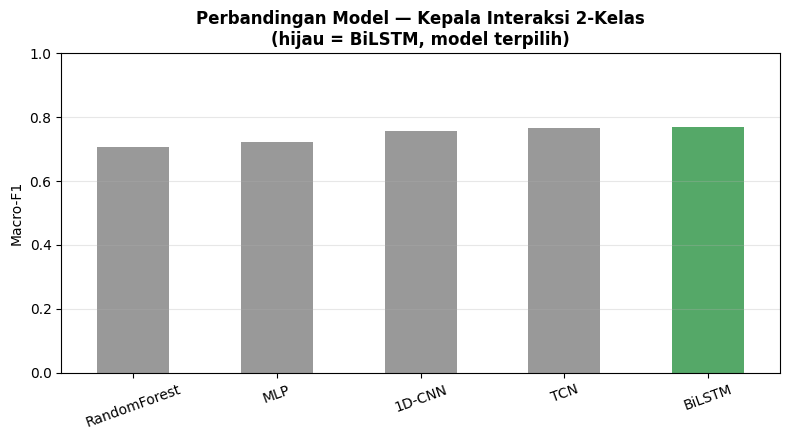


Tersimpan: interaction2_model_comparison.csv/.json, interaction2_comparison.png
>> Bandingkan dengan Tabel 3.7 proposal (6-kelas) untuk lihat apakah urutan performa
   model tetap konsisten setelah disederhanakan jadi 2 kelas.


In [10]:
# ============================================================================
# ===== CELL 9: MODEL PEMBANDING (RandomForest, MLP, 1D-CNN, TCN) =====
# ============================================================================
# Sama seperti Tabel 3.7 proposal (RandomForest/MLP/1D-CNN/TCN vs BiLSTM),
# tapi sekarang untuk 2-KELAS (inspecting vs other), bukan 6-kelas.
# CV & split IDENTIK dengan BiLSTM di atas (fold_splits sama, SEED sama)
# -> perbandingan adil, bukan pembanding yang beda kondisi.
#
# Model-model ini kecil & cepat (RF di CPU, yang lain di GPU) -> tidak makan
# banyak waktu tambahan. Checkpoint TIDAK diperlukan di sini karena tiap
# model cuma 1-3 menit per fold (beda dari BiLSTM yang lebih lama).

from sklearn.ensemble import RandomForestClassifier

# --- Model 1: RandomForest (baseline klasik, fitur diratakan) ---
def run_randomforest():
    print("\n=== RandomForest (2-kelas) ===")
    fold_res = []
    oof_rf = np.zeros(N, np.int64)
    for fold, (idx_tr, idx_va) in enumerate(fold_splits):
        Xtr_flat = X[idx_tr].reshape(len(idx_tr), -1)
        Xva_flat = X[idx_va].reshape(len(idx_va), -1)
        clf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                     class_weight="balanced", random_state=SEED, n_jobs=-1)
        clf.fit(Xtr_flat, y[idx_tr])
        pred = clf.predict(Xva_flat)
        oof_rf[idx_va] = pred
        m = full_metrics(y[idx_va], pred)
        fold_res.append(m)
        print(f"  fold {fold}: macroF1={m['macroF1']:.3f} recall_inspecting={m['recall_inspecting']:.3f}")
    return fold_res, oof_rf

# --- Model 2: MLP (flatten window, tanpa mekanisme temporal eksplisit) ---
class MLPBaseline(nn.Module):
    def __init__(self, in_dim, window_len, n_classes=2, hidden=256):
        super().__init__()
        flat_dim = in_dim * window_len          # <<< PERBAIKAN: kali window_len
        self.net = nn.Sequential(
            nn.Linear(flat_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden//2, n_classes))
    def forward(self, x):
        return self.net(x.reshape(x.shape[0], -1))

# --- Model 3: 1D-CNN (konvolusi temporal lokal) ---
class CNN1DBaseline(nn.Module):
    def __init__(self, in_dim, n_classes=2, channels=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_dim, channels, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size=5, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(channels, n_classes)
    def forward(self, x):
        x = x.transpose(1, 2)          # [B,T,D] -> [B,D,T] utk Conv1d
        return self.fc(self.conv(x).squeeze(-1))

# --- Model 4: TCN (dilated convolution, jangkauan reseptif lebih luas) ---
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU()
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.relu(self.conv(x) + self.res(x))

class TCNBaseline(nn.Module):
    def __init__(self, in_dim, n_classes=2, channels=64):
        super().__init__()
        self.blocks = nn.Sequential(
            TCNBlock(in_dim, channels, dilation=1),
            TCNBlock(channels, channels, dilation=2),
            TCNBlock(channels, channels, dilation=4))
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, n_classes)
    def forward(self, x):
        x = x.transpose(1, 2)
        return self.fc(self.pool(self.blocks(x)).squeeze(-1))


def run_torch_baseline(model_cls, name, epochs=25):
    print(f"\n=== {name} (2-kelas) ===")
    fold_res = []
    oof_pred_bl = np.zeros(N, np.int64)
    for fold, (idx_tr, idx_va) in enumerate(fold_splits):
        cnt = np.bincount(y[idx_tr], minlength=N_CLASSES).astype(np.float32)
        cw  = cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None))
        model = model_cls(IN_DIM).to(DEVICE)
        crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, device=DEVICE))
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        dl_tr, dl_va = make_loader(idx_tr, True), make_loader(idx_va, False)
        best_f1, best_pred = -1, None
        for ep in range(epochs):
            model.train()
            for xb, yb in dl_tr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            yv, pv = predict_proba(model, dl_va)
            m = full_metrics(yv, pv.argmax(1))
            if m["macroF1"] > best_f1:
                best_f1 = m["macroF1"]; best_pred = pv.argmax(1); best_m = m
        oof_pred_bl[idx_va] = best_pred
        fold_res.append(best_m)
        print(f"  fold {fold}: macroF1={best_m['macroF1']:.3f} recall_inspecting={best_m['recall_inspecting']:.3f}")
    return fold_res, oof_pred_bl

from functools import partial
# --- Jalankan semua pembanding ---
rf_res, rf_oof   = run_randomforest()

mlp_res, mlp_oof = run_torch_baseline(partial(MLPBaseline, window_len=X.shape[1]), "MLP")
cnn_res, cnn_oof = run_torch_baseline(CNN1DBaseline, "1D-CNN")
tcn_res, tcn_oof = run_torch_baseline(TCNBaseline, "TCN")

def summarize(fold_res):
    df = pd.DataFrame(fold_res)
    return {k: round(float(df[k].mean()), 4) for k in METRIC_COLS}

comparison = {
    "RandomForest": summarize(rf_res),
    "MLP": summarize(mlp_res),
    "1D-CNN": summarize(cnn_res),
    "TCN": summarize(tcn_res),
    "BiLSTM": summary["macroF1"],   # dari CELL 5, sudah dict {mean,std} -> ambil rata2 saja di bawah
}
comparison["BiLSTM"] = {k: summary[k]["mean"] for k in METRIC_COLS}

comp_df = pd.DataFrame(comparison).T[["acc","bal_acc","macroF1","weightedF1","mcc","kappa"]]
print("\n" + "="*70)
print("TABEL PERBANDINGAN — 2-KELAS (setara Tabel 3.7 proposal, tapi 2 kelas)")
print("="*70)
print(comp_df.to_string())

comp_df.to_csv(f"{MODEL_DIR}/interaction2_model_comparison.csv")
with open(f"{MODEL_DIR}/interaction2_model_comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)

fig, ax = plt.subplots(figsize=(8,4.5))
comp_df["macroF1"].plot(kind="bar", ax=ax, color=["#999","#999","#999","#999","#55A868"])
ax.set_ylabel("Macro-F1"); ax.set_ylim(0,1)
ax.set_title("Perbandingan Model — Kepala Interaksi 2-Kelas\n(hijau = BiLSTM, model terpilih)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(f"{MODEL_DIR}/interaction2_comparison.png", dpi=150); plt.show()

print(f"\nTersimpan: interaction2_model_comparison.csv/.json, interaction2_comparison.png")
print(">> Bandingkan dengan Tabel 3.7 proposal (6-kelas) untuk lihat apakah urutan performa")
print("   model tetap konsisten setelah disederhanakan jadi 2 kelas.")